<a href="https://colab.research.google.com/github/rafiff18/2025_Pengolahan_Citra-_TI-2B/blob/main/Jobsheet_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



*   Muhammad Rafif Pasya
* TI-2B
*   4.33.23.1.18



Praktikum 1. Transormasi Kurva (Citra Negatif)

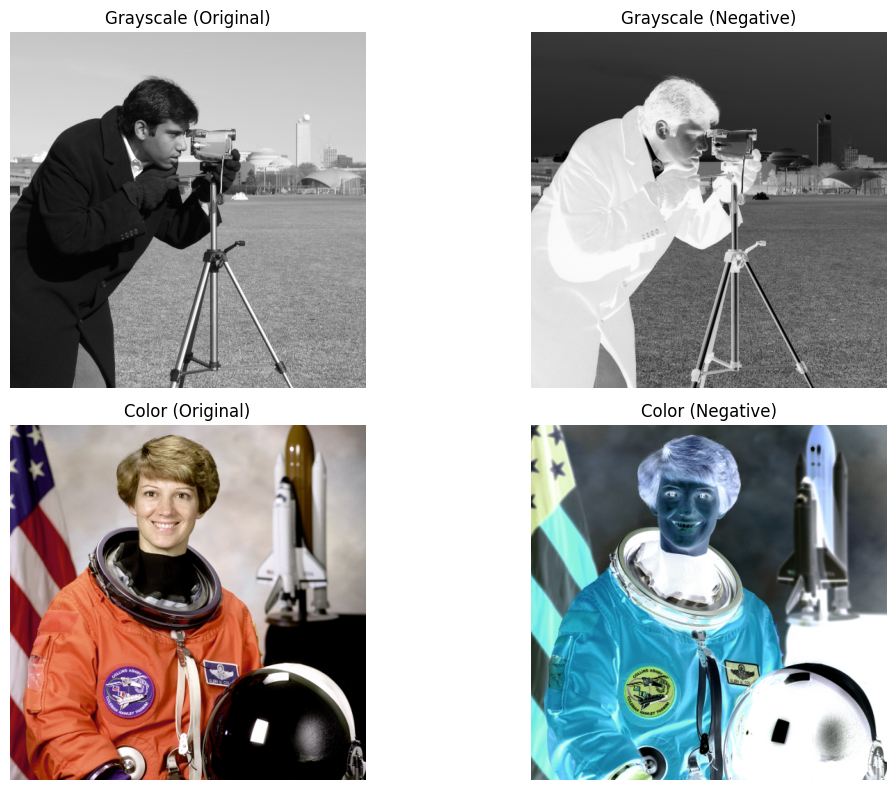

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ===================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ===================
image_gray_uint8 = data.camera()                          # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8)         # Konversi ke float [0..1]
negative_gray = 1.0 - image_gray_float                    # Inversi intensitas: output = 1 - input

# ===================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ===================
image_color_uint8 = data.astronaut()                      # Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)       # Konversi ke float [0..1]
negative_color = 1.0 - image_color_float                  # Inversi intensitas tiap kanal RGB

# ===================
# 3. PLOTTING HASIL
# ===================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


Praktikum 2. Histogram dan Ekualisasi Histogram

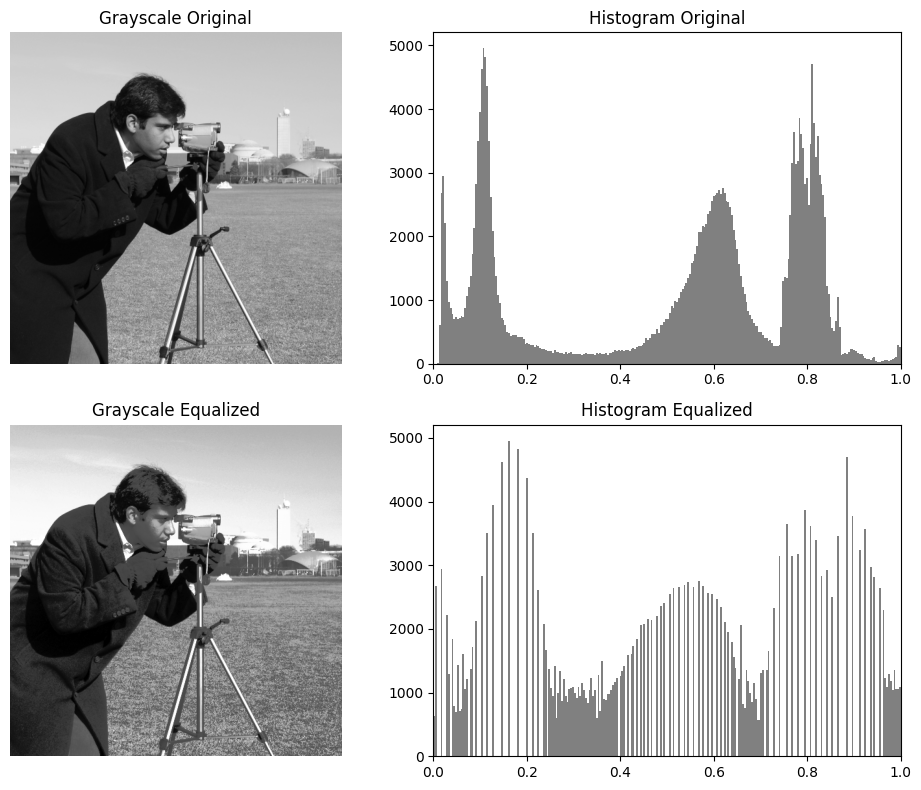

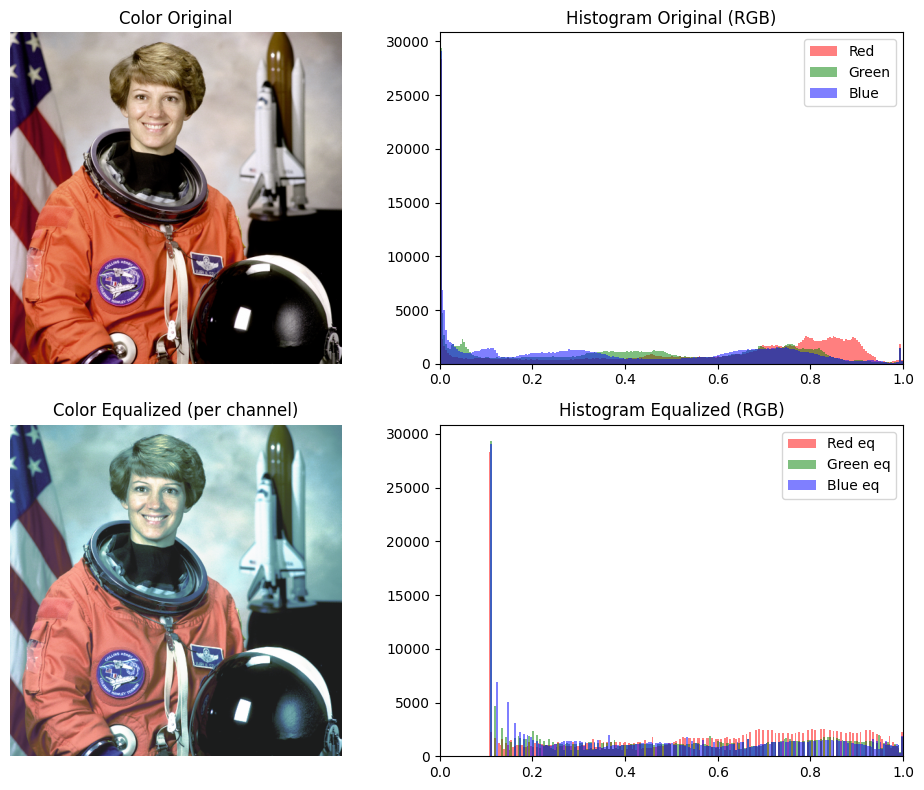

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# -----------------------------------------------------
# BAGIAN 1: HISTOGRAM & EKUALISASI HISTOGRAM (GRAYSCALE)
# -----------------------------------------------------

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera()  # sudah grayscale (uint8, 0..255)
image_gray = img_as_float(image_gray_uint8)  # konversi ke float [0..1]

# 2. Menghitung histogram citra asli
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot grayscale: citra asli & histogram, citra ekualisasi & histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli Grayscale
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Citra Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0, 1)

# (c) Citra Hasil Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Citra Hasil Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

# -------------------------------------------------------
# BAGIAN 2: HISTOGRAM & EKUALISASI HISTOGRAM (CITRA WARNA)
# -------------------------------------------------------

# 1. Memuat citra berwarna
image_color_uint8 = data.astronaut()  # citra berwarna RGB (uint8)
image_color = img_as_float(image_color_uint8)  # konversi ke float [0..1]

# 2. Histogram gabungan per kanal (R, G, B)
r_channel = image_color[:, :, 0]
g_channel = image_color[:, :, 1]
b_channel = image_color[:, :, 2]

hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0, 1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0, 1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram tiap kanal secara independen
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Histogram setelah ekualisasi
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0, 1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0, 1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot citra berwarna & histogram
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli (Color)
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# (b) Histogram Asli (tumpuk R, G, B)
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0, 1)
axes2[0, 1].legend(loc='upper right')

# (c) Citra Hasil Ekualisasi (RGB)
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

# (d) Histogram Ekualisasi (tumpuk R, G, B)
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim(0, 1)
axes2[1, 1].legend(loc='upper right')

plt.tight_layout()
plt.show()


Praktikum 3. Konvolusi (Filter Rata-rata)

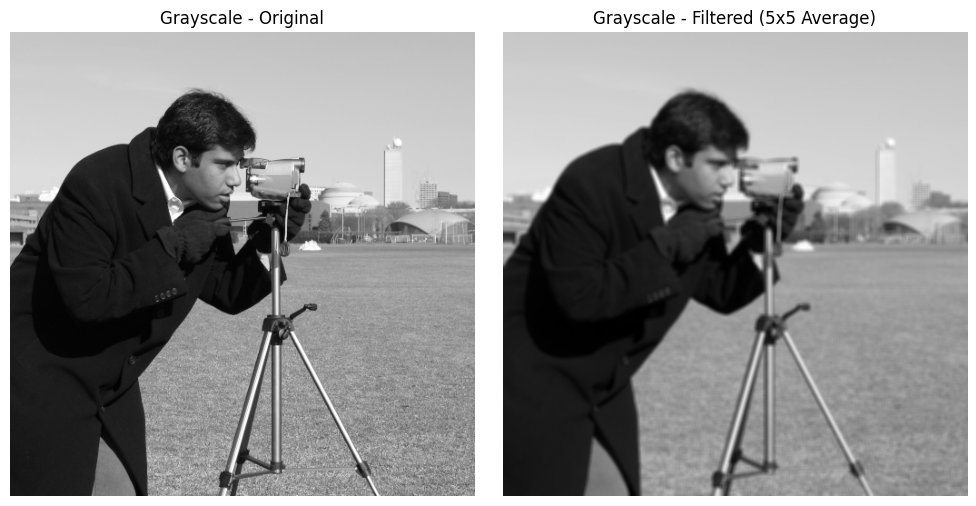

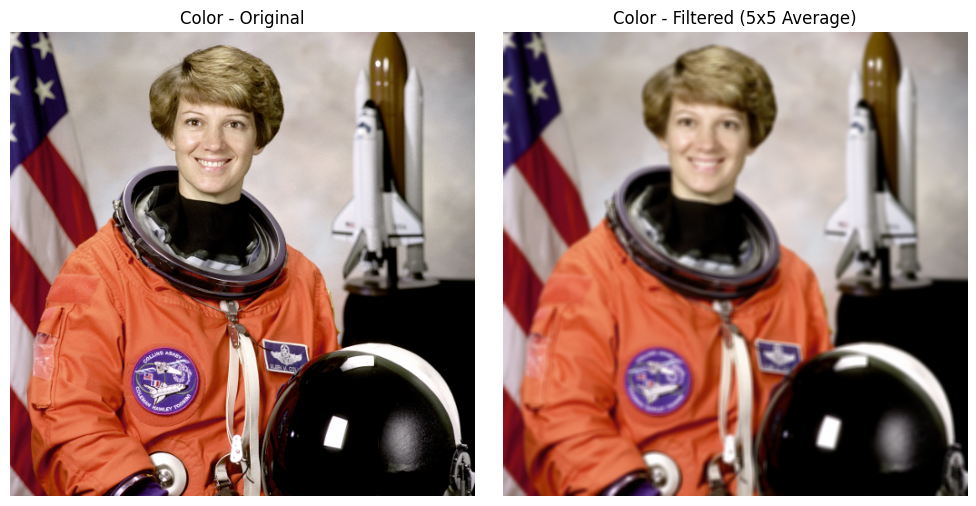

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

# A. Memuat citra grayscale (camera)
gray_uint8 = data.camera()  # range 0..255
gray_img = img_as_float(gray_uint8)  # konversi menjadi float [0..1] untuk kemudahan

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut()  # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8)  # konversi float [0..1]

# B. Kita akan terapkan filter rata-rata pada tiap kanal R, G, B secara terpisah, lalu gabungkan.
color_filtered = np.zeros_like(color_img)

for c in range(3):  # c = 0 (Red), 1 (Green), 2 (Blue)
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

# C. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()


Praktikum 4. Filter Median (penghilangan noise/derau)

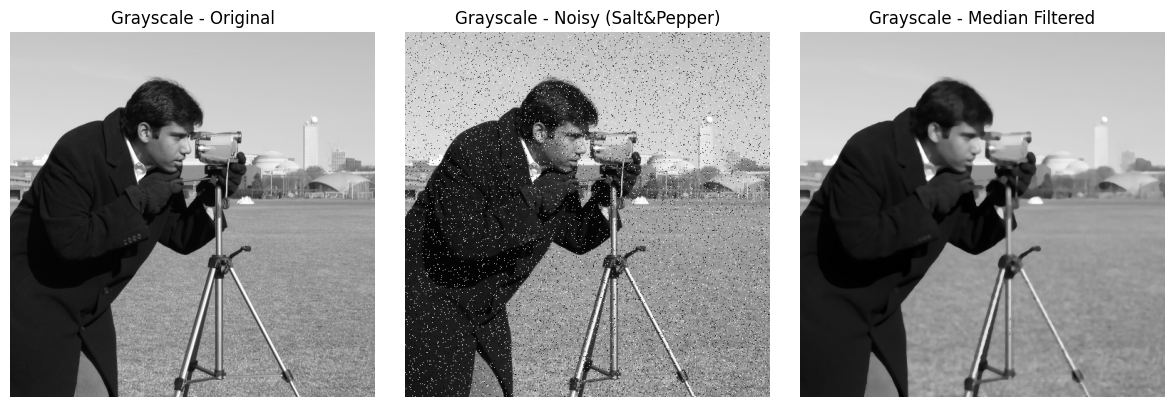

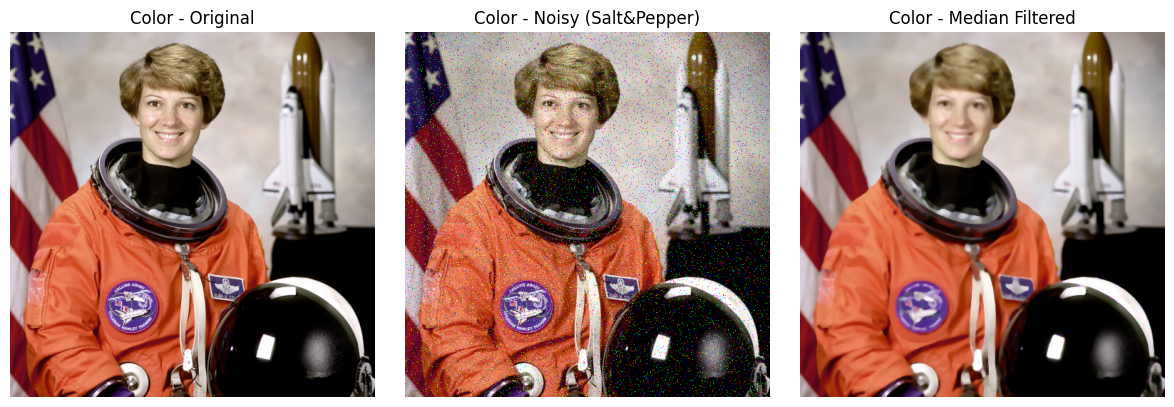

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# A. Memuat citra grayscale (contoh: 'camera')
gray_uint8 = data.camera()  # grayscale, uint8
gray_float = img_as_float(gray_uint8)  # konversi float [0..1]

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)
# amount=0.05 berarti 5% piksel terpengaruh noise

# C. Menerapkan filter median
# Kita gunakan structuring element berbentuk disk radius 3
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Plot hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# A. Memuat citra berwarna (contoh: 'astronaut')
color_uint8 = data.astronaut()  # RGB, uint8
color_float = img_as_float(color_uint8)  # rentang [0..1]

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median
# Pada scikit-image 0.19+, median() mampu menangani array 3D (RGB),
# atau kita bisa memanggil per kanal. Di sini langsung:
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Plot hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()


Tugas 1


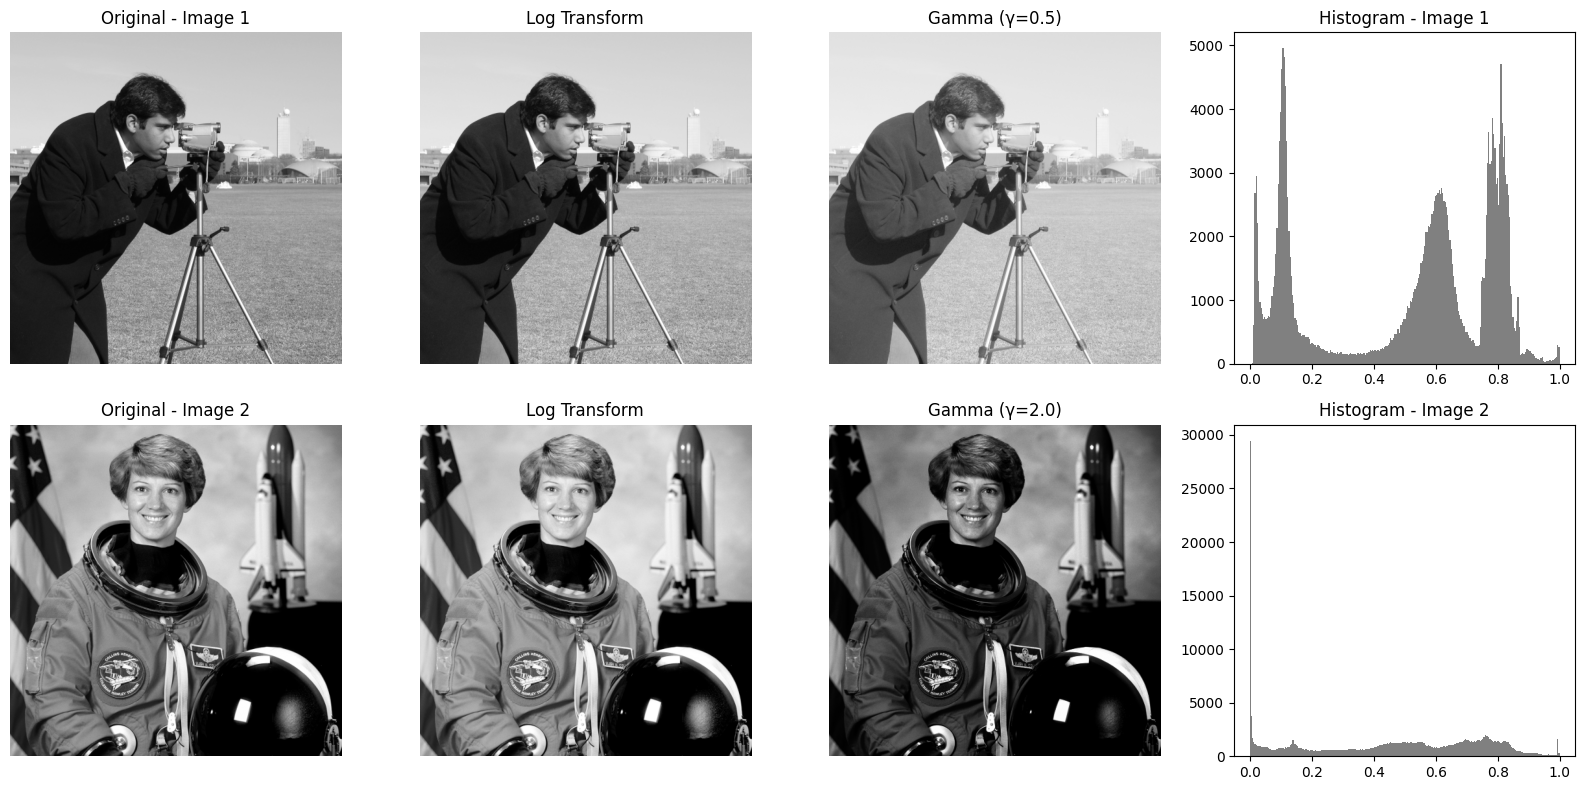

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, img_as_float

# 1. Memuat dua citra grayscale
image1 = img_as_float(data.camera())  # Citra grayscale 1
image2 = img_as_float(color.rgb2gray(data.astronaut()))  # Astronaut diubah jadi grayscale

# 2. Transformasi Logaritmik
def log_transform(image, c=1):
    return c * np.log1p(image)

# 3. Transformasi Gamma
def gamma_transform(image, c=1, gamma=1.0):
    return c * np.power(image, gamma)

# Terapkan transformasi ke kedua citra
log1 = log_transform(image1, c=1)
gamma1 = gamma_transform(image1, c=1, gamma=0.5)  # gamma < 1 (mencerahkan)
log2 = log_transform(image2, c=1)
gamma2 = gamma_transform(image2, c=1, gamma=2.0)  # gamma > 1 (menggelapkan)

# 4. Plot hasil transformasi
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# Baris 1: image1 (camera)
axes[0, 0].imshow(image1, cmap='gray')
axes[0, 0].set_title("Original - Image 1")
axes[0, 1].imshow(log1, cmap='gray')
axes[0, 1].set_title("Log Transform")
axes[0, 2].imshow(gamma1, cmap='gray')
axes[0, 2].set_title("Gamma (γ=0.5)")
axes[0, 3].hist(image1.ravel(), bins=256, color='gray')
axes[0, 3].set_title("Histogram - Image 1")

# Baris 2: image2 (astronaut grayscale)
axes[1, 0].imshow(image2, cmap='gray')
axes[1, 0].set_title("Original - Image 2")
axes[1, 1].imshow(log2, cmap='gray')
axes[1, 1].set_title("Log Transform")
axes[1, 2].imshow(gamma2, cmap='gray')
axes[1, 2].set_title("Gamma (γ=2.0)")
axes[1, 3].hist(image2.ravel(), bins=256, color='gray')
axes[1, 3].set_title("Histogram - Image 2")

# Nonaktifkan axis untuk semua gambar
for ax in axes.ravel():
    if ax not in [axes[0, 3], axes[1, 3]]:
        ax.axis('off')

plt.tight_layout()
plt.show()


Tugas 2


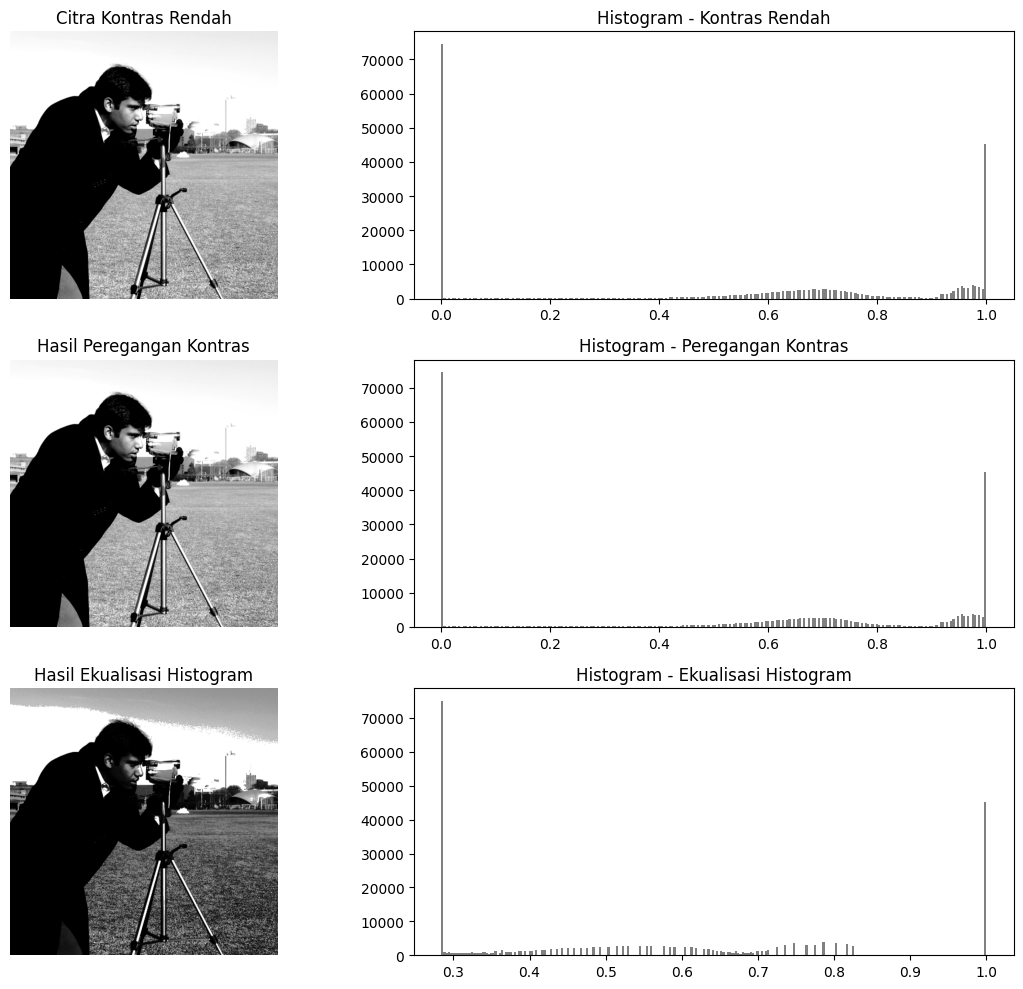

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, exposure

# 1. Ambil citra dan turunkan kontrasnya agar jadi rendah
original = img_as_float(data.camera())
low_contrast = exposure.rescale_intensity(original, in_range=(0.2, 0.8))

# 2. Tingkatkan kontras dengan dua metode
# a. Peregangan kontras
stretched = exposure.rescale_intensity(low_contrast)

# b. Ekualisasi histogram
equalized = exposure.equalize_hist(low_contrast)

# 3. Tampilkan citra dan histogramnya
fig, axes = plt.subplots(3, 2, figsize=(12, 10))

# Baris 1 - Citra kontras rendah
axes[0, 0].imshow(low_contrast, cmap='gray')
axes[0, 0].set_title('Citra Kontras Rendah')
axes[0, 0].axis('off')
axes[0, 1].hist(low_contrast.ravel(), bins=256, color='gray')
axes[0, 1].set_title('Histogram - Kontras Rendah')

# Baris 2 - Peregangan kontras
axes[1, 0].imshow(stretched, cmap='gray')
axes[1, 0].set_title('Hasil Peregangan Kontras')
axes[1, 0].axis('off')
axes[1, 1].hist(stretched.ravel(), bins=256, color='gray')
axes[1, 1].set_title('Histogram - Peregangan Kontras')

# Baris 3 - Ekualisasi histogram
axes[2, 0].imshow(equalized, cmap='gray')
axes[2, 0].set_title('Hasil Ekualisasi Histogram')
axes[2, 0].axis('off')
axes[2, 1].hist(equalized.ravel(), bins=256, color='gray')
axes[2, 1].set_title('Histogram - Ekualisasi Histogram')

plt.tight_layout()
plt.show()


Tugas 3

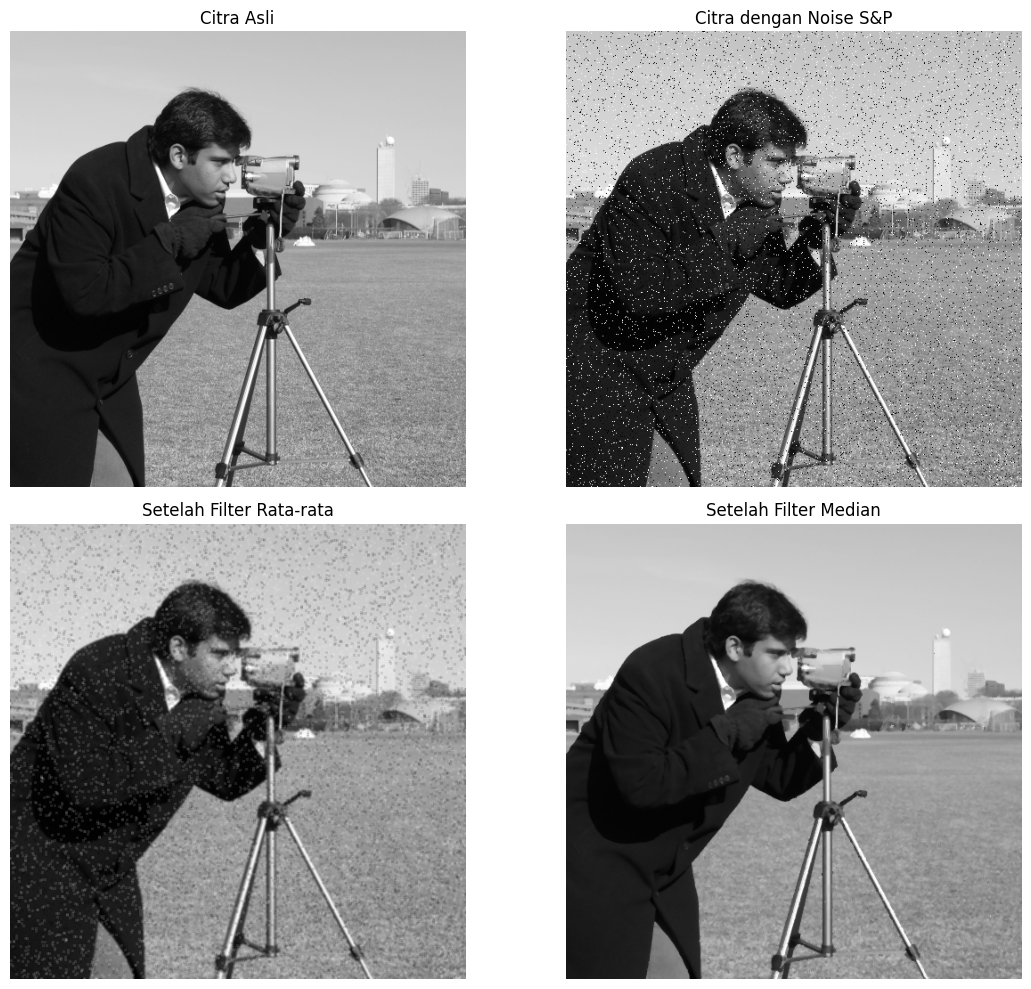

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, restoration
from scipy.ndimage import uniform_filter, median_filter

# 1. Ambil citra grayscale
image = data.camera()

# 2. Tambahkan noise salt-and-pepper
noisy_image = util.random_noise(image, mode='s&p')

# 3. Terapkan filter rata-rata (average filter)
avg_filtered = uniform_filter(noisy_image, size=3)

# 4. Terapkan filter median
med_filtered = median_filter(noisy_image, size=3)

# 5. Visualisasi hasil
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title("Citra Asli")
axes[0, 0].axis('off')

axes[0, 1].imshow(noisy_image, cmap='gray')
axes[0, 1].set_title("Citra dengan Noise S&P")
axes[0, 1].axis('off')

axes[1, 0].imshow(avg_filtered, cmap='gray')
axes[1, 0].set_title("Setelah Filter Rata-rata")
axes[1, 0].axis('off')

axes[1, 1].imshow(med_filtered, cmap='gray')
axes[1, 1].set_title("Setelah Filter Median")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()
